# Space Warps Candidate Ranking Tool

A notebook that improves gravitational lens candidate detection by combining:
- Volunteer classifications from Zooniverse
- Volunteer reliability weighting (better volunteers count more)
- AI confidence scores

Built as a contribution to the Space Warps ESA Euclid project.
Currently uses sample data — designed to accept real Zooniverse exports.

Author: Reginald Billot
Date: March 2026

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Create some sample Space Warps data
data = {
    'image_id': ['IMG_001', 'IMG_002', 'IMG_003', 'IMG_004', 'IMG_005',
                 'IMG_006', 'IMG_007', 'IMG_008', 'IMG_009', 'IMG_010'],
    'total_votes': [25, 22, 30, 18, 27, 24, 20, 29, 23, 26],
    'yes_votes':   [23, 20,  4, 16,  2, 13, 19, 28, 12,  1],
}

df = pd.DataFrame(data)
df['agreement'] = df['yes_votes'] / df['total_votes'] * 100

print(df)


  image_id  total_votes  yes_votes  agreement
0  IMG_001           25         23  92.000000
1  IMG_002           22         20  90.909091
2  IMG_003           30          4  13.333333
3  IMG_004           18         16  88.888889
4  IMG_005           27          2   7.407407
5  IMG_006           24         13  54.166667
6  IMG_007           20         19  95.000000
7  IMG_008           29         28  96.551724
8  IMG_009           23         12  52.173913
9  IMG_010           26          1   3.846154


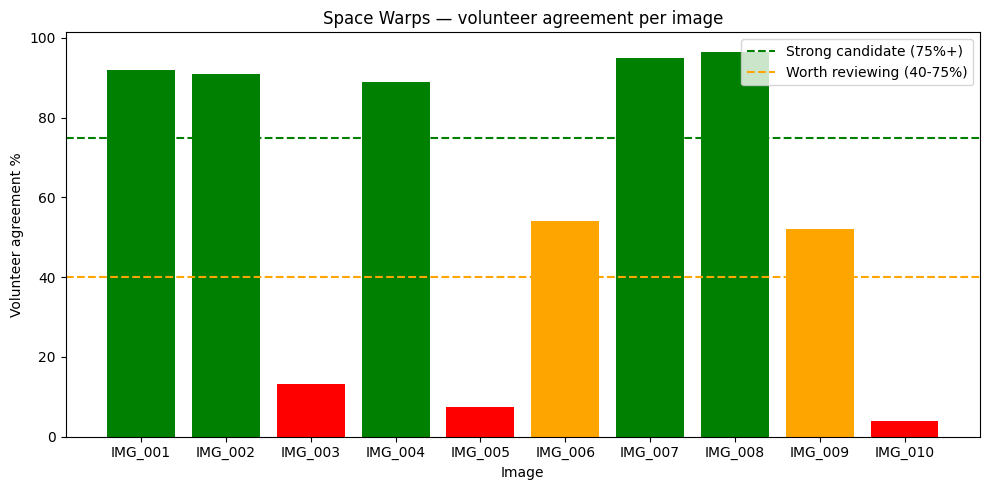

In [30]:
colors = []
for score in df['agreement']:
    if score >= 75:
        colors.append('green')
    elif score >= 40:
        colors.append('orange')
    else:
        colors.append('red')

plt.figure(figsize=(10, 5))
plt.bar(df['image_id'], df['agreement'], color=colors)
plt.axhline(y=75, color='green', linestyle='--', label='Strong candidate (75%+)')
plt.axhline(y=40, color='orange', linestyle='--', label='Worth reviewing (40-75%)')
plt.xlabel('Image')
plt.ylabel('Volunteer agreement %')
plt.title('Space Warps — volunteer agreement per image')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Add simulated AI confidence scores (0 to 1)
df['ai_score'] = [0.89, 0.85, 0.11, 0.91, 0.06, 0.61, 0.92, 0.95, 0.48, 0.03]

# Combine volunteer agreement and AI score into one final score
df['final_score'] = (df['agreement'] / 100 * 0.6) + (df['ai_score'] * 0.4)

# Sort best to worst
df_sorted = df.sort_values('final_score', ascending=False)

print(df_sorted[['image_id', 'agreement', 'ai_score', 'final_score']].to_string(index=False))

image_id  agreement  ai_score  final_score
 IMG_008  96.551724      0.95     0.959310
 IMG_007  95.000000      0.92     0.938000
 IMG_001  92.000000      0.89     0.908000
 IMG_004  88.888889      0.91     0.897333
 IMG_002  90.909091      0.85     0.885455
 IMG_006  54.166667      0.61     0.569000
 IMG_009  52.173913      0.48     0.505043
 IMG_003  13.333333      0.11     0.124000
 IMG_005   7.407407      0.06     0.068444
 IMG_010   3.846154      0.03     0.035077


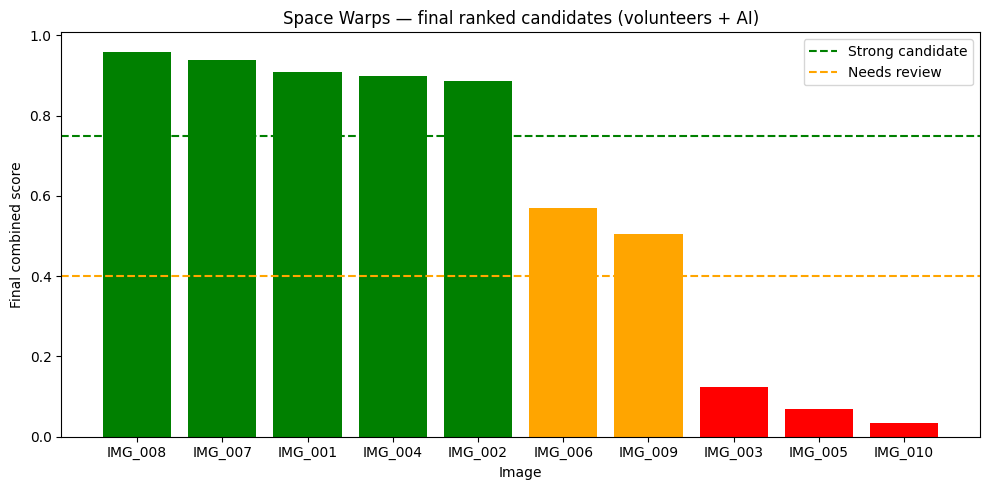

In [32]:
colors = []
for score in df_sorted['final_score']:
    if score >= 0.75:
        colors.append('green')
    elif score >= 0.40:
        colors.append('orange')
    else:
        colors.append('red')

plt.figure(figsize=(10, 5))
plt.bar(df_sorted['image_id'], df_sorted['final_score'], color=colors)
plt.axhline(y=0.75, color='green', linestyle='--', label='Strong candidate')
plt.axhline(y=0.40, color='orange', linestyle='--', label='Needs review')
plt.xlabel('Image')
plt.ylabel('Final combined score')
plt.title('Space Warps — final ranked candidates (volunteers + AI)')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Each volunteer's performance on the known test images
volunteers = {
    'user_A': {'correct': 18, 'total': 20},  # very reliable
    'user_B': {'correct': 11, 'total': 20},  # average
    'user_C': {'correct':  9, 'total': 20},  # barely better than guessing
    'user_D': {'correct': 19, 'total': 20},  # very reliable
    'user_E': {'correct':  6, 'total': 20},  # unreliable
}

# Calculate each volunteer's reliability score
for user, stats in volunteers.items():
    stats['reliability'] = stats['correct'] / stats['total']
    print(f"{user}: {stats['correct']}/{ stats['total']} correct — reliability {stats['reliability']:.0%}")

user_A: 18/20 correct — reliability 90%
user_B: 11/20 correct — reliability 55%
user_C: 9/20 correct — reliability 45%
user_D: 19/20 correct — reliability 95%
user_E: 6/20 correct — reliability 30%


In [34]:
# Simulate which volunteers looked at each image and how they voted
import random
random.seed(42)

user_list = list(volunteers.keys())

def weighted_agreement(image_votes):
    weighted_yes = 0
    weighted_total = 0
    for user, vote in image_votes.items():
        reliability = volunteers[user]['reliability']
        weighted_yes += vote * reliability
        weighted_total += reliability
    return weighted_yes / weighted_total

# Simulate votes for each image in our dataset
image_votes = {
    'IMG_001': {'user_A':1, 'user_B':1, 'user_D':1, 'user_C':1, 'user_E':0},
    'IMG_002': {'user_A':1, 'user_B':1, 'user_D':1, 'user_C':0, 'user_E':1},
    'IMG_003': {'user_A':0, 'user_B':0, 'user_D':0, 'user_C':1, 'user_E':1},
    'IMG_004': {'user_A':1, 'user_B':1, 'user_D':1, 'user_C':1, 'user_E':0},
    'IMG_005': {'user_A':0, 'user_B':0, 'user_D':0, 'user_C':0, 'user_E':1},
    'IMG_006': {'user_A':1, 'user_B':0, 'user_D':1, 'user_C':0, 'user_E':1},
    'IMG_007': {'user_A':1, 'user_B':1, 'user_D':1, 'user_C':1, 'user_E':1},
    'IMG_008': {'user_A':1, 'user_B':1, 'user_D':1, 'user_C':1, 'user_E':1},
    'IMG_009': {'user_A':0, 'user_B':1, 'user_D':0, 'user_C':1, 'user_E':1},
    'IMG_010': {'user_A':0, 'user_B':0, 'user_D':0, 'user_C':0, 'user_E':0},
}

# Calculate both old and new scores for every image
results = []
for img_id, votes in image_votes.items():
    old_score = sum(votes.values()) / len(votes)
    new_score = weighted_agreement(votes)
    ai = df[df['image_id'] == img_id]['ai_score'].values[0]
    final = (new_score * 0.6) + (ai * 0.4)
    results.append({
        'image_id': img_id,
        'old_score': round(old_score, 2),
        'weighted_score': round(new_score, 2),
        'ai_score': ai,
        'final_score': round(final, 2)
    })

df_results = pd.DataFrame(results).sort_values('final_score', ascending=False)
print(df_results.to_string(index=False))

image_id  old_score  weighted_score  ai_score  final_score
 IMG_008        1.0            1.00      0.95         0.98
 IMG_007        1.0            1.00      0.92         0.97
 IMG_004        0.8            0.90      0.91         0.91
 IMG_001        0.8            0.90      0.89         0.90
 IMG_002        0.8            0.86      0.85         0.85
 IMG_006        0.6            0.68      0.61         0.65
 IMG_009        0.6            0.41      0.48         0.44
 IMG_003        0.4            0.24      0.11         0.19
 IMG_005        0.2            0.10      0.06         0.08
 IMG_010        0.0            0.00      0.03         0.01


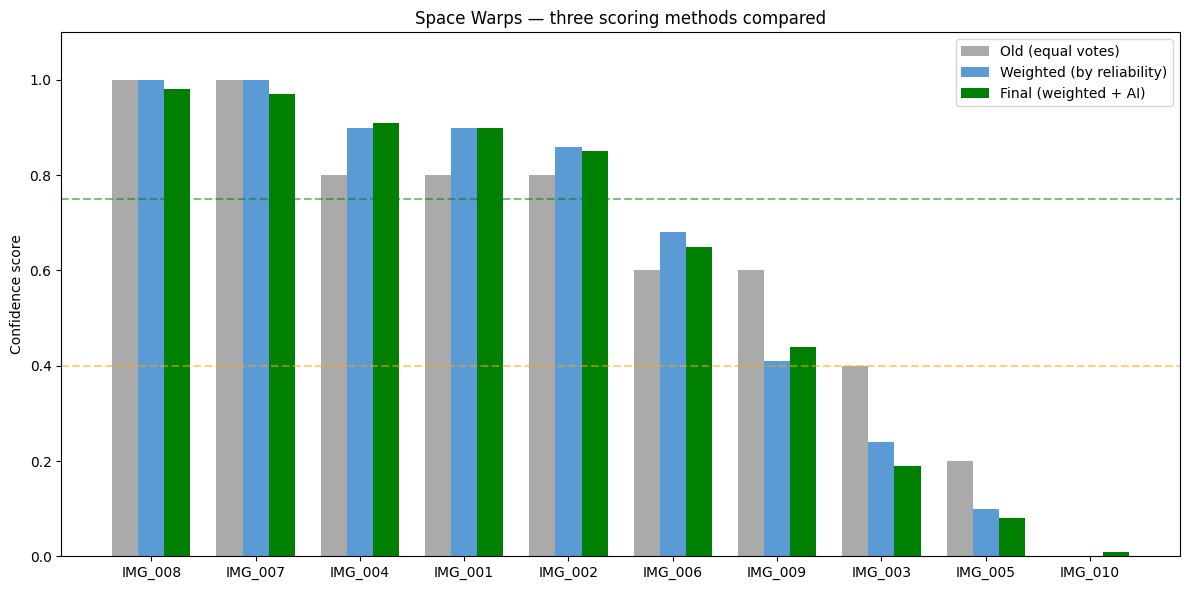

In [35]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_results))
width = 0.25

bars1 = ax.bar(x - width, df_results['old_score'],
               width, label='Old (equal votes)',
               color='#aaaaaa')
bars2 = ax.bar(x, df_results['weighted_score'],
               width, label='Weighted (by reliability)',
               color='#5b9bd5')
bars3 = ax.bar(x + width, df_results['final_score'],
               width, label='Final (weighted + AI)',
               color='green')

ax.axhline(y=0.75, color='green', linestyle='--', alpha=0.5)
ax.axhline(y=0.40, color='orange', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(df_results['image_id'])
ax.set_ylabel('Confidence score')
ax.set_title('Space Warps — three scoring methods compared')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()